In [83]:
#!pip install pandas numpy 
#!pip install nltk
#!pip install plotly
#!pip install wordcloud

#!pip install scikit-learn

  Using cached scikit_learn-1.6.0-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached scipy-1.14.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.0-cp312-cp312-win_amd64.whl (11.1 MB)
Using cached scipy-1.14.1-cp312-cp312-win_amd64.whl (44.5 MB)
Using cached threadpoolctl-3.5.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import data from a website using the requests library and format it as a reusable DataFrame.

In [26]:
import requests
import pandas as pd 
def extract_all_data():
    x=["1000","2000","3000","4000","5500"]
    data= ""
    for x_i in x:
        data += requests.get(f'https://cogcomp.seas.upenn.edu/Data/QA/QC/train_{x_i}.label').text
        data += "\n"
    data_list=data.split("\n")
    data_json = {
        "target" : [],
        "question" : [] 
    }
    for d in data_list :
        try:
          if(len(d) > 0) :
            index = d.index(':') #The index() method in Python is used to find the first occurrence of a specified value within a string
            label, question = d[:index],d[index+1:]
            data_json["target"].append(label)
            data_json["question"].append(question)
        except:
            print(d)
    return data_json
        
        
train_data=pd.DataFrame(extract_all_data())


# Exploration 

In [27]:
train_data.head()


,target,question
0,DESC,manner How did serfdom develop in and then lea...
1,ENTY,cremat What films featured the character Popey...
2,DESC,manner How can I find a list of celebrities ' ...
3,ENTY,animal What fowl grabs the spotlight after the...
4,ABBR,exp What is the full form of .com ?


In [35]:
for x in train_data["target"].unique() :
    print(x)

DESC
ENTY
ABBR
HUM
NUM
LOC


#  Data Preprocessing

In [56]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
tokens = word_tokenize(" Hello word i am his bitch ") 
stop_words = set(stopwords.words('english'))
p = PorterStemmer()
# methode to clean text 
def clean_tokenize (text):
    text = text.lower()
    text= " ".join( [w for w in word_tokenize(text) if w not in stop_words ])
    return  " ".join([ p.stem(w) for w in word_tokenize(text) ] ) 


In [57]:
import math 
def calcul_tf(text,text1):
    #(Number of times term t appears in a document)/(Number of terms in the document)
    tokens = word_tokenize(text)
    Tf = {}
    for t in tokens :
        if t not in Tf.keys():
            Tf[t] =1
        else :
            Tf[t] +=1
    total_terms = len(tokens)  
    for (k,v) in Tf.items():
        Tf[k] = v/total_terms
    return Tf
def calcul_idf(text,tex2):
    tf = calcul_tf(text,text2)
    idf = {}
    # Combine the texts to simulate a corpus
    all_texts = [text,text2]
    all_tokens = [ word_tokenize(word) for word in all_texts ]
    num_docs = len(all_texts)
    for term in tf:
        doc_count = sum(1 for tokens in all_tokens if term in tokens)
        idf[term] = math.log(num_docs / (1 + doc_count))
    TFIDF= {}
    for k in tf:
        TFIDF[k]= idf[k]*tf[k]
    return  TFIDF
text1 = "This is a sample document."
text2 = "This document is a sample example for testing TF-IDF."

tfidf_result = calcul_idf(text1, text2)
print("TF-IDF Results:")
for word, score in tfidf_result.items():
    print(f"{word}: {score:.4f}")
    

        
    
    
    

    

TF-IDF Results:
This: -0.0676
is: -0.0676
a: -0.0676
sample: -0.0676
document: -0.0676
.: -0.0676


In [58]:
"""
To get the frequency distribution of the words in the text, we can utilize the nltk.FreqDist() function, 
which lists the top words used in the text, providing a rough idea of the main topic in the text data
"""


'\nTo get the frequency distribution of the words in the text, we can utilize the nltk.FreqDist() function, \nwhich lists the top words used in the text, providing a rough idea of the main topic in the text data\n'

In [97]:
questions = train_data.question.str.cat(sep = ' ')
tokens = word_tokenize(questions)
tokens = [w for w in tokens if not w in stop_words]
vocabulary = set(tokens)
frequency_dist = nltk.FreqDist(tokens)
tokens
#sorted(frequency_dist,key=frequency_dist.__getitem__, reverse=True)[0:50]

['manner',
 'How',
 'serfdom',
 'develop',
 'leave',
 'Russia',
 '?',
 'cremat',
 'What',
 'films',
 'featured',
 'character',
 'Popeye',
 'Doyle',
 '?',
 'manner',
 'How',
 'I',
 'find',
 'list',
 'celebrities',
 "'",
 'real',
 'names',
 '?',
 'animal',
 'What',
 'fowl',
 'grabs',
 'spotlight',
 'Chinese',
 'Year',
 'Monkey',
 '?',
 'exp',
 'What',
 'full',
 'form',
 '.com',
 '?',
 'ind',
 'What',
 'contemptible',
 'scoundrel',
 'stole',
 'cork',
 'lunch',
 '?',
 'gr',
 'What',
 'team',
 'baseball',
 "'s",
 'St.',
 'Louis',
 'Browns',
 'become',
 '?',
 'title',
 'What',
 'oldest',
 'profession',
 '?',
 'def',
 'What',
 'liver',
 'enzymes',
 '?',
 'ind',
 'Name',
 'scar-faced',
 'bounty',
 'hunter',
 'The',
 'Old',
 'West',
 '.',
 'date',
 'When',
 'Ozzy',
 'Osbourne',
 'born',
 '?',
 'reason',
 'Why',
 'heavier',
 'objects',
 'travel',
 'downhill',
 'faster',
 '?',
 'ind',
 'Who',
 'The',
 'Pride',
 'Yankees',
 '?',
 'ind',
 'Who',
 'killed',
 'Gandhi',
 '?',
 'event',
 'What',
 'cons

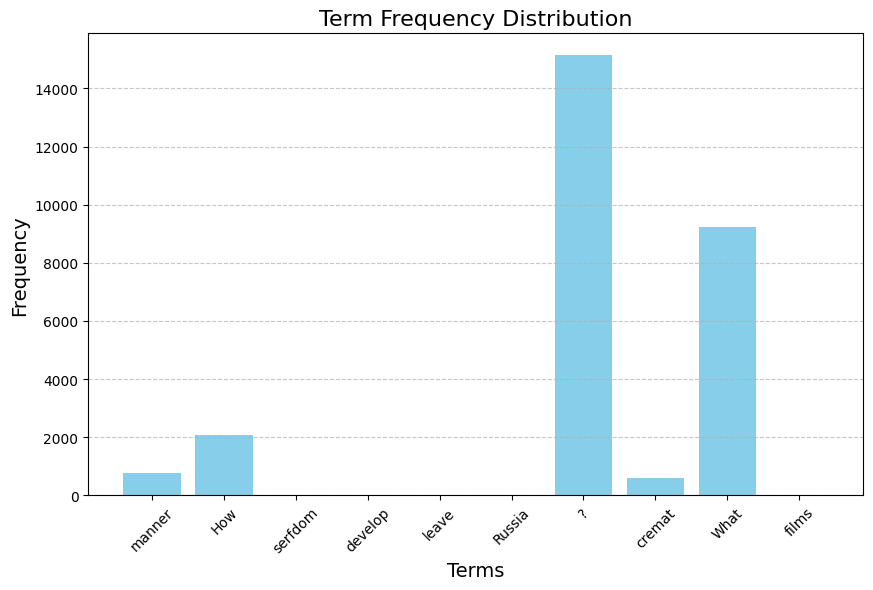

In [75]:
import matplotlib.pyplot as plt

terms = list(frequency_dist.keys())[0:10]
frequencies = list(frequency_dist.values())[0:10]

# Bar chart
plt.figure(figsize=(10, 6))
plt.bar(terms, frequencies, color='skyblue')
plt.xlabel("Terms", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Term Frequency Distribution", fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [78]:
import plotly.express as px

data = sorted(frequency_dist.items(), key=lambda x: x[1], reverse=True)[:10]
df = {"Terms": [item[0] for item in data], "Frequency": [item[1] for item in data]}

fig = px.bar(df, x="Terms", y="Frequency", title="Term Frequency Distribution", text="Frequency")
fig.update_traces(marker_color='lightblue', textposition='outside')
fig.update_layout(xaxis_tickangle=45)
fig.show()


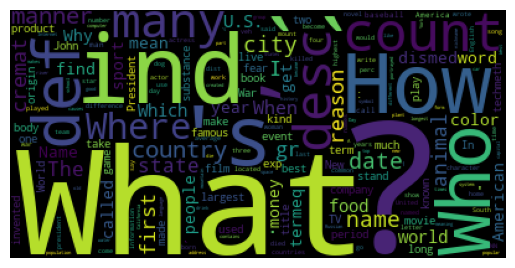

In [81]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wordcloud = WordCloud().generate_from_frequencies(frequency_dist)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# Building a Classifier


In [94]:
from sklearn.model_selection import train_test_split
X,y = train_data.question,train_data.target
(X_train, X_test, y_train, y_test) = train_test_split(X, y,test_size = .2,random_state = 22)


 # methode 1

In [95]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
train_vectors = vectorizer.fit_transform(X_train)
test_vectors = vectorizer.transform(X_test)
print(train_vectors.shape, test_vectors.shape)

(12361, 8138) (3091, 8138)


In [107]:
corpus = list(train_data.question )
vocabulary = set(corpus)

new_corpus = []
for c in corpus :
    new_corpus.append(clean_tokenize(c))


# methode 2 

In [112]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline

pipe = Pipeline([('count', CountVectorizer(vocabulary=vocabulary)),
                 ('tfid', TfidfTransformer())]).fit(new_corpus)
new_data = pipe.fit_transform(new_corpus).toarray()


In [113]:
from sklearn.naive_bayes import MultinomialNB
clf = MultinomialNB().fit(X_train, y_train)

In [114]:
clf

MultinomialNB()

In [115]:
from  sklearn.metrics  import accuracy_score
predicted = clf.predict(X_test)
print(accuracy_score(y_test,predicted))

0.228405046910385
